Kaggle Dataset link for the code:https://www.kaggle.com/datasets/atharvjairath/personachat

Dataset: (8939, 3)

Classification report:
               precision    recall  f1-score   support

           0       1.00      0.23      0.37        22
           1       0.69      1.00      0.82        38

    accuracy                           0.72        60
   macro avg       0.85      0.61      0.59        60
weighted avg       0.80      0.72      0.65        60

Precision=0.691, Recall=1.000, F1=0.817


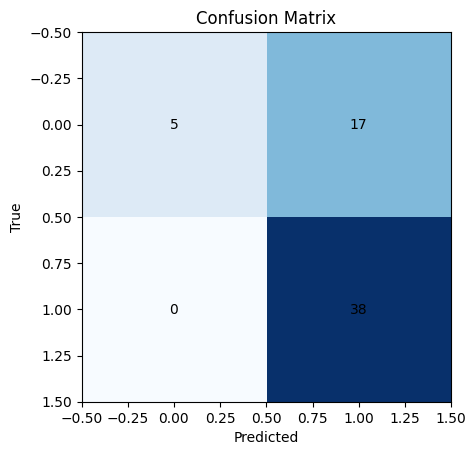

In [ ]:
# train_and_evaluate.py
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, precision_recall_fscore_support, confusion_matrix


df = pd.read_csv("/content/personality.csv", on_bad_lines='skip', low_memory=False)
print("Dataset:", df.shape)

texts = df['Persona'].fillna("").astype(str).tolist()
vect = TfidfVectorizer(max_features=1000, stop_words="english")
X = vect.fit_transform(texts)
kmeans = KMeans(n_clusters=2, random_state=42, n_init=5).fit(X)
y = kmeans.labels_

n_samples = min(200, len(texts))
rng = np.random.RandomState(42)
idx = rng.choice(range(len(texts)), size=n_samples, replace=False)
Xs = X[idx]
ys = y[idx]

X_train, X_test, y_train, y_test = train_test_split(Xs, ys, test_size=0.3, random_state=42, stratify=ys)
clf = LogisticRegression(max_iter=300).fit(X_train, y_train)
y_pred = clf.predict(X_test)
print("\nClassification report:\n", classification_report(y_test, y_pred, zero_division=0))
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="binary", zero_division=0)
print(f"Precision={precision:.3f}, Recall={recall:.3f}, F1={f1:.3f}")
cm = confusion_matrix(y_test, y_pred)
plt.imshow(cm, cmap="Blues")
for (i,j), val in np.ndenumerate(cm):
    plt.text(j, i, str(val), ha="center", va="center")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [ ]:
!pip install faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.4/31.4 MB 28.3 MB/s eta 0:00:00


In [ ]:
# rag_local.py
import pandas as pd, numpy as np
import faiss
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, pipeline

df = pd.read_csv("/content/personality.csv")
docs = df['Persona'].fillna("").astype(str).tolist()[:500]

embedder = SentenceTransformer('all-MiniLM-L6-v2')
embs = embedder.encode(docs, convert_to_numpy=True)
faiss.normalize_L2(embs)
index = faiss.IndexFlatIP(embs.shape[1])
index.add(embs)

def retrieve(q, k=3):
    q_emb = embedder.encode([q], convert_to_numpy=True)
    faiss.normalize_L2(q_emb)
    D,I = index.search(q_emb, k)
    return [(int(I[0,i]), docs[I[0,i]], float(D[0,i])) for i in range(k)]

tok = AutoTokenizer.from_pretrained("google/flan-t5-small")
model = AutoModelForSeq2SeqLM.from_pretrained("google/flan-t5-small")
gen = pipeline("text2text-generation", model=model, tokenizer=tok)

def answer(q):
    hits = retrieve(q, k=3)
    ctx = "\n".join([h[1] for h in hits])
    prompt = f"Context:\n{ctx}\n\nPlayer: {q}\nRPG GM Response:"
    return gen(prompt, max_length=150, do_sample=False)[0]['generated_text']

if __name__ == "__main__":
    q = "I sneak into the barracks and listen"
    print("Query:", q)
    print("Answer:", answer(q))

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Device set to use cuda:0


Query: I sneak into the barracks and listen


Both `max_new_tokens` (=256) and `max_length`(=150) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Answer: i listen to a lot of metal music


In [ ]:
# rag_openai_scaffold.py
import os, pandas as pd, numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer


df = pd.read_csv("/content/personality.csv")
docs = df['Persona'].fillna("").astype(str).tolist()[:1000]

vect = TfidfVectorizer(max_features=2000, stop_words="english")
X = vect.fit_transform(docs)

def retrieve(q, k=3):
    vq = vect.transform([q])
    scores = (X @ vq.T).toarray().squeeze()
    idx = np.argsort(-scores)[:k]
    return [(i, docs[i], float(scores[i])) for i in idx]

def compose_prompt(q, hits):
    ctx = "\n".join([h[1] for h in hits])
    return f"You are an RPG GM. Use this context:\n{ctx}\n\nPlayer: {q}\nResponse:"

if __name__ == "__main__":
    q = "I sneak into the barracks and listen"
    hits = retrieve(q, 3)
    prompt = compose_prompt(q, hits)
    print("Prompt:\n", prompt[:500], "...\n")

Prompt:
 You are an RPG GM. Use this context:
 my mom is a janitor. i still live at home. i am in college. i listen to death metal.
 i am in college. my mom is a janitor. i listen to death metal. i like cartoons.
 my wardrobe is all band tees. i am an anime fan. i listen to techno music , exclusively. my job involves building drones.

Player: I sneak into the barracks and listen
Response: ...



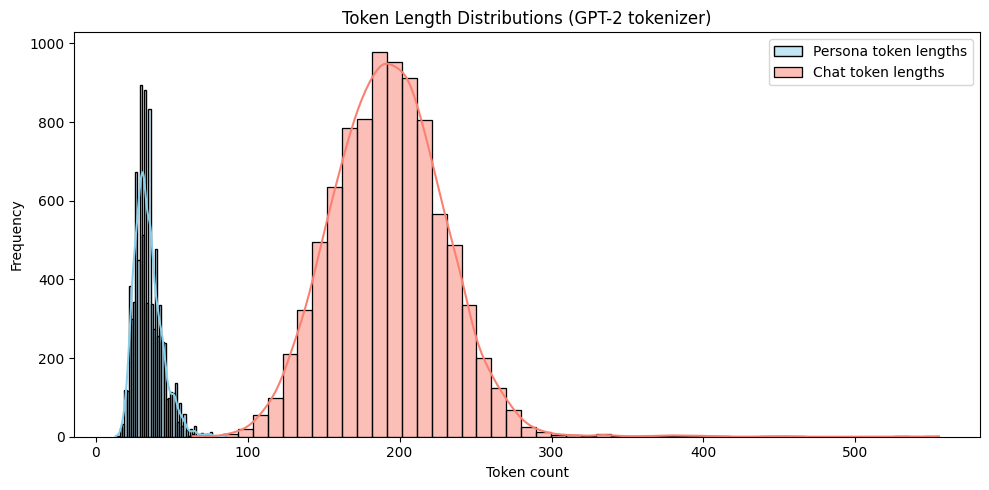

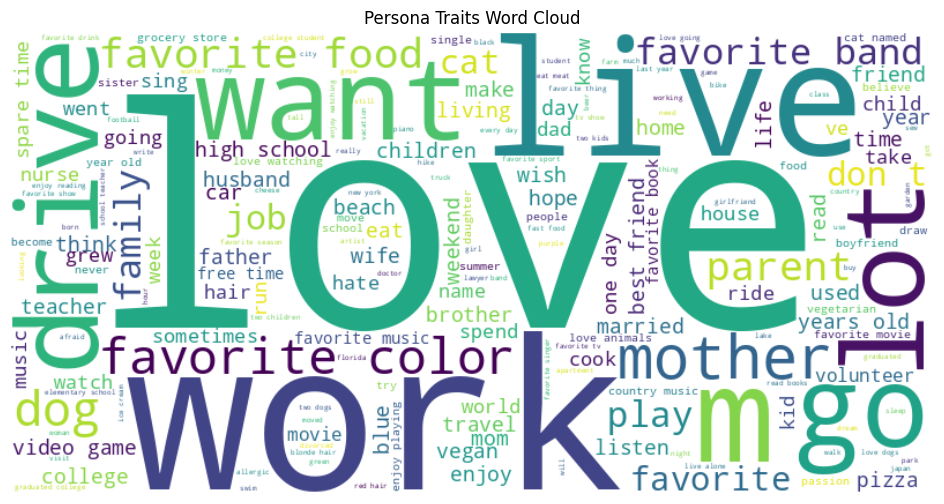

In [ ]:
# tokenize_and_visualize.py
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from transformers import AutoTokenizer
df = pd.read_csv("/content/personality.csv")
personas = df['Persona'].fillna("").astype(str).tolist()
chats = df['chat'].fillna("").astype(str).tolist()
tokenizer = AutoTokenizer.from_pretrained("gpt2")
token_lens = [len(tokenizer.encode(p)) for p in personas]
chat_lens = [len(tokenizer.encode(c)) for c in chats]
plt.figure(figsize=(10,5))
sns.histplot(token_lens, bins=50, color="skyblue", label="Persona token lengths", kde=True)
sns.histplot(chat_lens, bins=50, color="salmon", label="Chat token lengths", kde=True)
plt.legend()
plt.title("Token Length Distributions (GPT-2 tokenizer)")
plt.xlabel("Token count")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()
text_blob = " ".join(personas)
wc = WordCloud(width=800, height=400, background_color="white").generate(text_blob)
plt.figure(figsize=(12,6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Persona Traits Word Cloud")
plt.show()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 3.7 MB/s eta 0:00:00


tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/792 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/3.04G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.04G [00:00<?, ?B/s]

BLEU score: 0.028560275920749938
BERTScore F1 (avg): 0.5356539505720138


Batches:   0%|          | 0/32 [00:00<?, ?it/s]

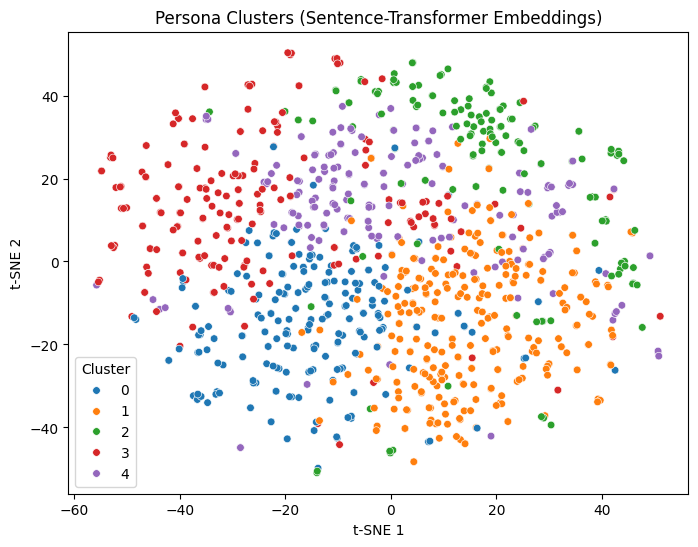

In [ ]:
!pip install evaluate
!pip install bert_score
# semantic_eval_and_clusters.py
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sentence_transformers import SentenceTransformer
import numpy as np
import evaluate
df = pd.read_csv("/content/personality.csv")
personas = df['Persona'].fillna("").astype(str).tolist()
chats = df['chat'].fillna("").astype(str).tolist()
bleu = evaluate.load("bleu")
bertscore = evaluate.load("bertscore")
sample_personas = personas[:200]
sample_chats = chats[:200]

bleu_res = bleu.compute(predictions=sample_chats, references=[[p] for p in sample_personas])
bertscore_res = bertscore.compute(predictions=sample_chats, references=sample_personas, model_type="microsoft/deberta-xlarge-mnli")

print("BLEU score:", bleu_res["bleu"])
print("BERTScore F1 (avg):", np.mean(bertscore_res["f1"]))

embedder = SentenceTransformer("all-MiniLM-L6-v2")
embs = embedder.encode(personas[:1000], show_progress_bar=True)

kmeans = KMeans(n_clusters=5, random_state=42).fit(embs)
labels = kmeans.labels_
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
embs_2d = tsne.fit_transform(embs)
plt.figure(figsize=(8,6))
sns.scatterplot(x=embs_2d[:,0], y=embs_2d[:,1], hue=labels, palette="tab10", s=30)
plt.title("Persona Clusters (Sentence-Transformer Embeddings)")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(title="Cluster")
plt.show()


--- Running model: MiniLM (sentence-transformers/all-MiniLM-L6-v2) ---


Batches:   0%|          | 0/10 [00:00<?, ?it/s]

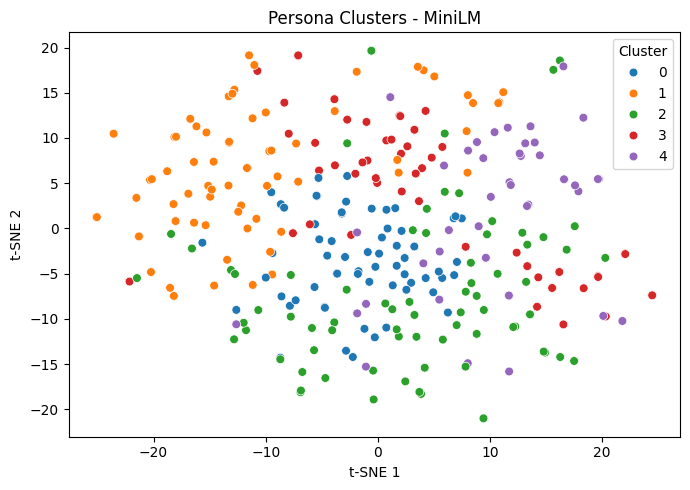

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/729 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.62G [00:00<?, ?B/s]

...

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]

Batches:   0%|          | 0/10 [00:00<?, ?it/s]

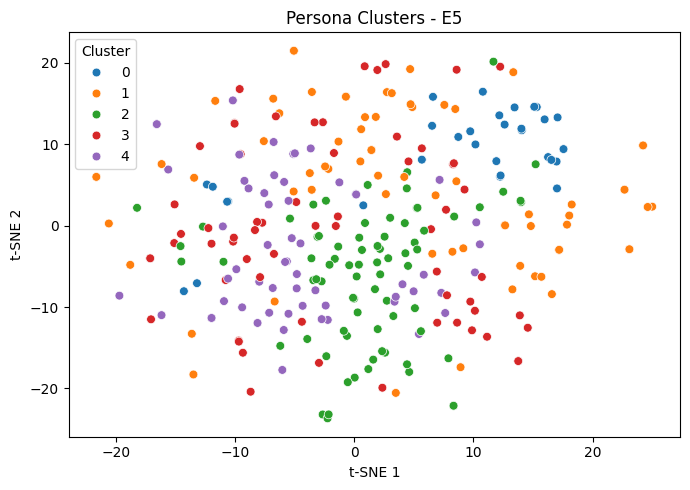


--- Running model: BGE (BAAI/bge-small-en) ---


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/10 [00:00<?, ?it/s]

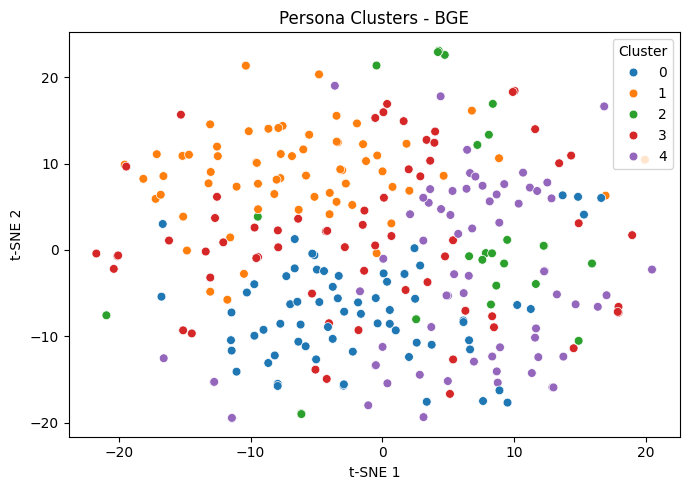


=== Model Comparison ===
           BLEU   BERT-F1
MiniLM  0.02769  0.511932
E5      0.02769  0.511932
BGE     0.02769  0.511932


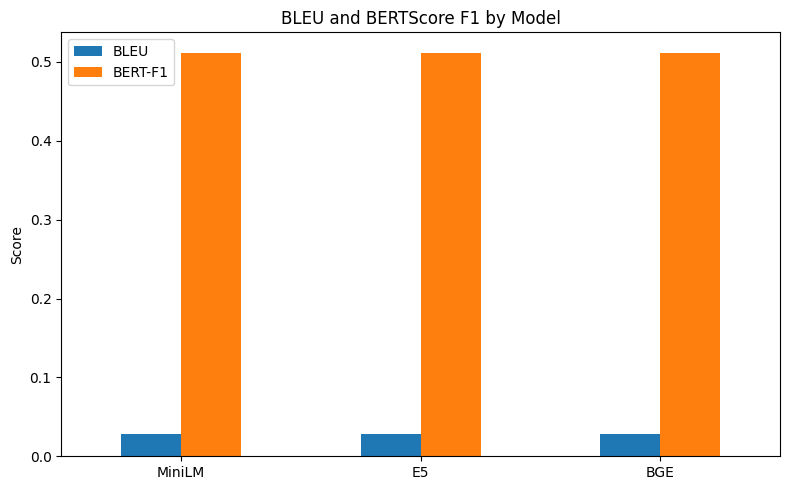

In [ ]:
# compare_open_llms.py
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sentence_transformers import SentenceTransformer
import evaluate
df = pd.read_csv("/content/personality.csv")
personas = df['Persona'].fillna("").astype(str).tolist()
chats = df['chat'].fillna("").astype(str).tolist()
N = 300
personas_sample = personas[:N]
chats_sample = chats[:N]
bleu = evaluate.load("bleu")
bertscore = evaluate.load("bertscore")
models = {
    "MiniLM": "sentence-transformers/all-MiniLM-L6-v2",
    "E5": "intfloat/multilingual-e5-base",
    "BGE": "BAAI/bge-small-en"
}

results = {}

for name, model_name in models.items():
    print(f"\n--- Running model: {name} ({model_name}) ---")
    embedder = SentenceTransformer(model_name)
    embs = embedder.encode(personas_sample, show_progress_bar=True, convert_to_numpy=True)
    kmeans = KMeans(n_clusters=5, random_state=42).fit(embs)
    labels = kmeans.labels_
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    embs_2d = tsne.fit_transform(embs)
    plt.figure(figsize=(7,5))
    sns.scatterplot(x=embs_2d[:,0], y=embs_2d[:,1], hue=labels, palette="tab10", s=40)
    plt.title(f"Persona Clusters - {name}")
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.legend(title="Cluster")
    plt.tight_layout()
    plt.show()
    bleu_res = bleu.compute(predictions=chats_sample, references=[[p] for p in personas_sample])
    bert_res = bertscore.compute(predictions=chats_sample, references=personas_sample, model_type="microsoft/deberta-large-mnli")

    bleu_score = bleu_res["bleu"]
    bert_f1 = np.mean(bert_res["f1"])

    results[name] = {"BLEU": bleu_score, "BERT-F1": bert_f1}
res_df = pd.DataFrame(results).T
print("\n=== Model Comparison ===")
print(res_df)
res_df.plot(kind="bar", figsize=(8,5))
plt.title("BLEU and BERTScore F1 by Model")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# preprocess_data.py
import pandas as pd
from sklearn.model_selection import train_test_split
persona_df = pd.read_csv("/content/personality.csv")
print("Personality dataset:", persona_df.shape)
persona_df = persona_df[['Persona', 'chat']].dropna()
pairs = []
for _, row in persona_df.iterrows():
    pairs.append({
        "input": f"Persona: {row['Persona']}\nPrompt:",
        "output": row['chat']
    })

df_pairs = pd.DataFrame(pairs)
train, test = train_test_split(df_pairs, test_size=0.1, random_state=42)

train.to_csv("train.csv", index=False)
test.to_csv("test.csv", index=False)
print("Saved train.csv and test.csv")


Personality dataset: (8939, 3)
Saved train.csv and test.csv


In [ ]:
# finetune_gpt2.py
from transformers import GPT2Tokenizer, GPT2LMHeadModel, Trainer, TrainingArguments, TextDataset, DataCollatorForLanguageModeling
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2LMHeadModel.from_pretrained("gpt2")
def load_dataset(path):
    return TextDataset(
        tokenizer=tokenizer,
        file_path=path,
        block_size=128
    )

train_dataset = load_dataset("train.csv")
test_dataset = load_dataset("test.csv")

data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

training_args = TrainingArguments(
    output_dir="./gpt2-rpg",
    overwrite_output_dir=True,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    num_train_epochs=1,
    save_steps=1000,
    save_total_limit=1,
    logging_dir="./logs",
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    data_collator=data_collator,
    train_dataset=train_dataset,
    eval_dataset=test_dataset
)

trainer.train()
trainer.save_model("./gpt2-rpg")

/usr/local/lib/python3.12/dist-packages/transformers/data/datasets/language_modeling.py:53: FutureWarning: This dataset will be removed from the library soon, preprocessing should be handled with the 🤗 Datasets library. You can have a look at this example script for pointers: https://github.com/huggingface/transformers/blob/main/examples/pytorch/language-modeling/run_mlm.py
  warnings.warn(
`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Step,Training Loss
500,3.134300
1000,2.938700
1500,2.894400
2000,2.839200
2500,2.845900
3000,2.801100
3500,2.758200
4000,2.772000
4500,2.721000
5000,2.709300


In [ ]:
import os
if os.path.exists("train.csv") and os.path.exists("test.csv"):
    print("train.csv and test.csv found.")
else:
    print("train.csv and/or test.csv not found. Regenerating preprocessing cell.")
    print("Please run the preprocessing cell (the one that saves train.csv and test.csv) before running the finetuning cell.")

train.csv and test.csv found.


In [ ]:
# rpg_play.py
from transformers import GPT2Tokenizer, GPT2LMHeadModel

tokenizer = GPT2Tokenizer.from_pretrained("./gpt2-rpg")
model = GPT2LMHeadModel.from_pretrained("./gpt2-rpg")

def generate_response(persona, player_input, max_length=80):
    input_text = f"Persona: {persona}\nPrompt: {player_input}\nResponse:"
    inputs = tokenizer.encode(input_text, return_tensors="pt")
    outputs = model.generate(inputs, max_length=max_length, pad_token_id=tokenizer.eos_token_id)
    return tokenizer.decode(outputs[0], skip_special_tokens=True)
persona = "I am a knight who protects the village."
print("Persona set:", persona)
while True:
    user = input("Player: ")
    if user.lower() in ["quit", "exit"]:
        break
    response = generate_response(persona, user)
    print("RPG:", response)

Persona set: I am a knight who protects the village.
Player: i sneak into the barracks and listen


The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


RPG: Persona: I am a knight who protects the village.
Prompt: i sneak into the barracks and listen
Response: i am a soldier , i am a soldier too .
i am a soldier too , i am a soldier too .
i am a soldier too , i am a soldier too .
i am a soldier too , i am a soldier too .
i am a
Player: what type of soldier are you?
RPG: Persona: I am a knight who protects the village.
Prompt: what type of soldier are you?
Response: i am a knight who protect the village .
i am a soldier , i am a soldier too .
i am a soldier too , i am a soldier too .
i am a soldier too , i am a soldier too .
i am a soldier too ,
Player: from who you protect the village from?
RPG: Persona: I am a knight who protects the village.
Prompt: from who you protect the village from?
Response: i am a knight who is a champion in the knightly court .
i am a knight who is a champion in the knightly court .
i am a knight who is a champion in the knightly court .
i am a knight who is a champion
Player: do you wear shield?
RPG: Person

In [ ]:
!pip install rouge_score

  Preparing metadata (setup.py) ... done
  Created wheel for rouge_score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=ab8802e62ab8431d4f22575cdd9d1ddea7378664a0c3fd416ab7e155d5ad4f3f
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge_score


In [ ]:
# evaluate_model.py
import pandas as pd
import evaluate
from transformers import GPT2Tokenizer, GPT2LMHeadModel
import torch, numpy as np
test = pd.read_csv("test.csv")
tokenizer = GPT2Tokenizer.from_pretrained("./gpt2-rpg")
model = GPT2LMHeadModel.from_pretrained("./gpt2-rpg")

bleu = evaluate.load("bleu")
rouge = evaluate.load("rouge")
bertscore = evaluate.load("bertscore")

predictions, references = [], []

for _, row in test.iterrows():
    input_text = row['input']
    inputs = tokenizer.encode(input_text, return_tensors="pt")
    outputs = model.generate(inputs, max_length=128, pad_token_id=tokenizer.eos_token_id)
    pred = tokenizer.decode(outputs[0], skip_special_tokens=True)
    predictions.append(pred)
    references.append(row['output'])

print("BLEU:", bleu.compute(predictions=predictions, references=[[r] for r in references])["bleu"])
print("ROUGE:", rouge.compute(predictions=predictions, references=references))
print("BERTScore:", np.mean(bertscore.compute(predictions=predictions, references=references, model_type="microsoft/deberta-xlarge-mnli")["f1"]))
import math
def perplexity(sentence):
    enc = tokenizer.encode(sentence, return_tensors="pt")
    with torch.no_grad():
        loss = model(enc, labels=enc).loss
    return math.exp(loss.item())

print("Sample Perplexity:", perplexity(references[0]))

BLEU: 0.045969264894669334
ROUGE: {'rouge1': np.float64(0.31701441494481797), 'rouge2': np.float64(0.09405672936192995), 'rougeL': np.float64(0.19148627482880254), 'rougeLsum': np.float64(0.3023842604732403)}
BERTScore: 0.5179086067199173
Sample Perplexity: 13.933432555252105


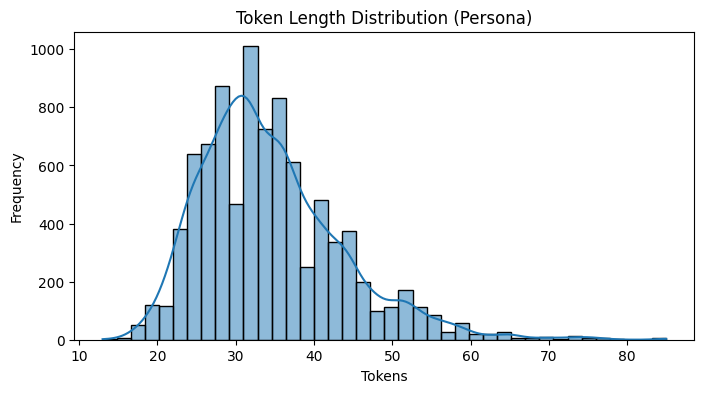

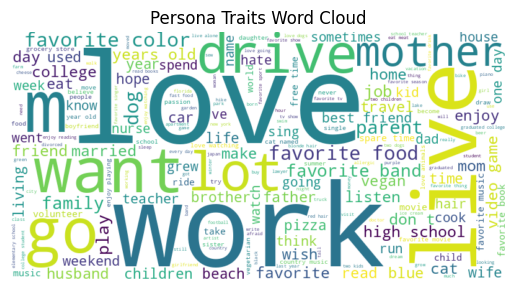

In [ ]:
# visualize_tokens.py
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer
from wordcloud import WordCloud
df = pd.read_csv("/content/personality.csv")

tokenizer = AutoTokenizer.from_pretrained("gpt2")
lens = [len(tokenizer.encode(t)) for t in df['Persona'].fillna("").astype(str)]
plt.figure(figsize=(8,4))
sns.histplot(lens, bins=40, kde=True)
plt.title("Token Length Distribution (Persona)")
plt.xlabel("Tokens")
plt.ylabel("Frequency")
plt.show()
text_blob = " ".join(df['Persona'].dropna().astype(str).tolist())
wc = WordCloud(width=800, height=400, background_color="white").generate(text_blob)
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Persona Traits Word Cloud")
plt.show()